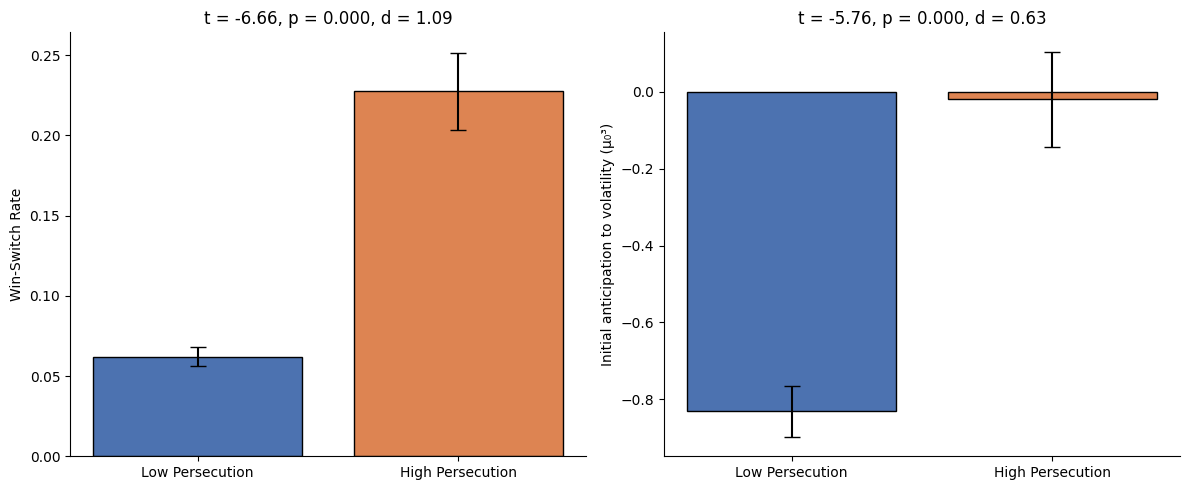

{'wsr_means': {'low': 0.06210052181395349, 'high': 0.22759391037373738},
 'wsr_sems': {'low': 0.006050303540375172, 'high': 0.02411292260302009},
 'wsr_t_p_d': (np.float64(-6.657), np.float64(0.0), np.float64(1.09)),
 'mu_means': {'low': -0.8315456380620154, 'high': -0.019650242050505043},
 'mu_sems': {'low': 0.06667974286208929, 'high': 0.12422262637878773},
 'mu_t_p_d': (np.float64(-5.759), np.float64(0.0), np.float64(0.63))}

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, ttest_ind
import numpy as np

# Load dataset
df = pd.read_csv('mp_scores_continuous_500.csv')

# Filter to necessary columns and drop missing
df_plot = df.dropna(subset=['persecution_group', 'wsr_avg', 'mu03_avg'])

# Define group labels
groups = ['low', 'high']
labels = ['Low Persecution', 'High Persecution']

# Compute means and SEMs for WSR
wsr_means = df_plot.groupby('persecution_group')['wsr_avg'].mean().reindex(groups)
wsr_sems = df_plot.groupby('persecution_group')['wsr_avg'].apply(sem).reindex(groups)

# Compute means and SEMs for mu03
mu_means = df_plot.groupby('persecution_group')['mu03_avg'].mean().reindex(groups)
mu_sems = df_plot.groupby('persecution_group')['mu03_avg'].apply(sem).reindex(groups)

# t-tests
wsr_low = df_plot[df_plot['persecution_group'] == 'low']['wsr_avg']
wsr_high = df_plot[df_plot['persecution_group'] == 'high']['wsr_avg']
t_wsr, p_wsr = ttest_ind(wsr_low, wsr_high, equal_var=False)

mu_low = df_plot[df_plot['persecution_group'] == 'low']['mu03_avg']
mu_high = df_plot[df_plot['persecution_group'] == 'high']['mu03_avg']
t_mu, p_mu = ttest_ind(mu_low, mu_high, equal_var=False)

# Calculate pooled standard deviation for Cohen's d
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

d_wsr = cohens_d(wsr_high, wsr_low)
d_mu = cohens_d(mu_high, mu_low)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# WSR Plot
axes[0].bar(labels, wsr_means.values, yerr=wsr_sems.values, capsize=6,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[0].set_title(f't = {t_wsr:.2f}, p = {p_wsr:.3f}, d = {d_wsr:.2f}')
axes[0].set_ylabel('Win-Switch Rate')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# mu03 Plot
axes[1].bar(labels, mu_means.values, yerr=mu_sems.values, capsize=6,
            color=['#4C72B0', '#DD8452'], edgecolor='black')
axes[1].set_title(f't = {t_mu:.2f}, p = {p_mu:.3f}, d = {d_mu:.2f}')
axes[1].set_ylabel('Initial anticipation to volatility (μ₀³)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

{
    'wsr_means': wsr_means.to_dict(),
    'wsr_sems': wsr_sems.to_dict(),
    'wsr_t_p_d': (round(t_wsr, 3), round(p_wsr, 3), round(d_wsr, 2)),
    'mu_means': mu_means.to_dict(),
    'mu_sems': mu_sems.to_dict(),
    'mu_t_p_d': (round(t_mu, 3), round(p_mu, 3), round(d_mu, 2))
}


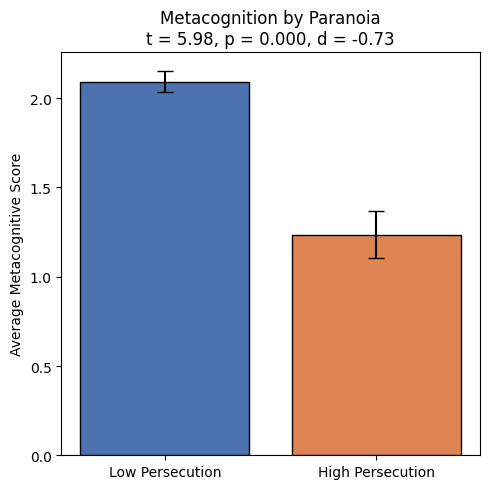

{'mp_means': {'low': 2.092609819121447, 'high': 1.236161616161616},
 'mp_sems': {'low': 0.05786904982365373, 'high': 0.13089063535028664},
 'mp_t_p': (np.float64(5.984), np.float64(0.0)),
 'cohen_d': np.float64(-0.73)}

In [ ]:
# MP_avg comparison using the original pooled SD method

# Define MP dimensions
mp_columns = [
    'comprehension_continuous',
    'judgment_continuous',
    'evaluation_continuous',
    'final_decision_continuous',
    'confidence_continuous'
]

# Drop rows missing MP dimensions or persecution_group
df_mp = df.dropna(subset=mp_columns + ['persecution_group']).copy()

# Compute average MP score
df_mp['MP_avg'] = df_mp[mp_columns].mean(axis=1)

# Define group labels
groups = ['low', 'high']
labels = ['Low Persecution', 'High Persecution']

# Compute means and SEMs for MP_avg
mp_means = df_mp.groupby('persecution_group')['MP_avg'].mean().reindex(groups)
mp_sems = df_mp.groupby('persecution_group')['MP_avg'].apply(sem).reindex(groups)

# Split data for t-test and pooled Cohen's d
mp_low = df_mp[df_mp['persecution_group'] == 'low']['MP_avg']
mp_high = df_mp[df_mp['persecution_group'] == 'high']['MP_avg']

# t-test
t_mp, p_mp = ttest_ind(mp_low, mp_high, equal_var=False)

cohen_d_mp = cohens_d(mp_high, mp_low)  # high - low to match t-test direction

# Plot
plt.figure(figsize=(5, 5))
plt.bar(labels, mp_means.values, yerr=mp_sems.values, capsize=6,
        color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.title(f'Metacognition by Paranoia\nt = {t_mp:.2f}, p = {p_mp:.3f}, d = {cohen_d_mp:.2f}')
plt.ylabel('Average Metacognitive Score')
plt.tight_layout()
plt.show()

# Output for replication
{
    'mp_means': mp_means.to_dict(),
    'mp_sems': mp_sems.to_dict(),
    'mp_t_p': (round(t_mp, 3), round(p_mp, 3)),
    'cohen_d': round(cohen_d_mp, 2)
}


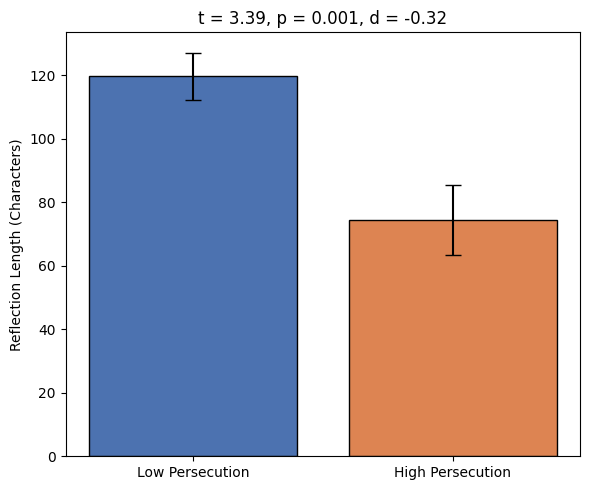

{'char_means': {'low': 119.75968992248062, 'high': 74.43434343434343}, 'char_sems': {'low': 7.4561167477993555, 'high': 11.118300554416527}, 'char_t_p_d': (np.float64(3.386), np.float64(0.001), np.float64(-0.32))}


In [ ]:
# Standalone Reflection Length Plot
# Compute character count
df_plot['char_count'] = df_plot['combined_reflection'].astype(str).apply(len)

# Group stats
char_means = df_plot.groupby('persecution_group')['char_count'].mean().reindex(groups)
char_sems = df_plot.groupby('persecution_group')['char_count'].apply(sem).reindex(groups)

# Extract groups for stats
char_low = df_plot[df_plot['persecution_group'] == 'low']['char_count']
char_high = df_plot[df_plot['persecution_group'] == 'high']['char_count']

# T-test and Cohen's d
t_char, p_char = ttest_ind(char_low, char_high, equal_var=False)
d_char = cohens_d(char_high, char_low)

# Plot
plt.figure(figsize=(6, 5))
plt.bar(labels, char_means.values, yerr=char_sems.values, capsize=6,
        color=['#4C72B0', '#DD8452'], edgecolor='black')
plt.ylabel('Reflection Length (Characters)')
plt.title(f't = {t_char:.2f}, p = {p_char:.3f}, d = {d_char:.2f}')
plt.xticks(labels)
plt.tight_layout()
plt.show()

print({
    'char_means': char_means.to_dict(),
    'char_sems': char_sems.to_dict(),
    'char_t_p_d': (round(t_char, 3), round(p_char, 3), round(d_char, 2))
})


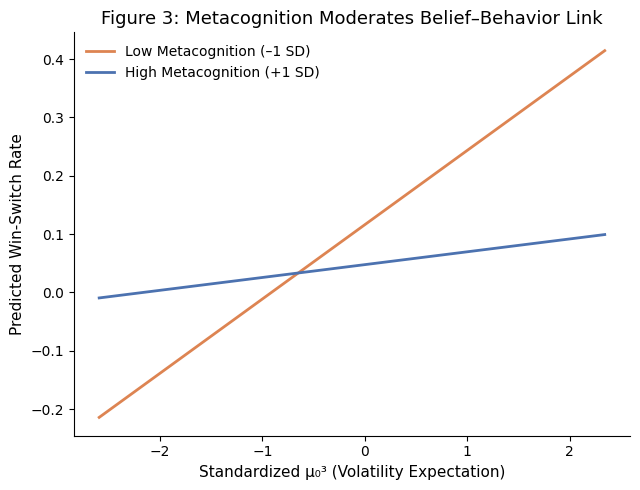

In [ ]:
# Define moderation model
from sklearn.preprocessing import StandardScaler
import numpy as np
import statsmodels.formula.api as smf

# Load dataset again
df = pd.read_csv('mp_scores_continuous_500.csv')

# Define MP dimensions and calculate MP_avg
mp_columns = [
    'comprehension_continuous',
    'judgment_continuous',
    'evaluation_continuous',
    'final_decision_continuous',
    'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)

# Filter for moderation variables
df_moderation = df.dropna(subset=['mu03_avg', 'wsr_avg', 'MP_avg']).copy()

# Standardize
scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z']] = scaler.fit_transform(df_moderation[['mu03_avg', 'MP_avg']])
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# Fit model
model = smf.ols('wsr_avg ~ mu03_z * MP_z', data=df_moderation).fit()

# Re-run moderation plot
mu_range = np.linspace(df_moderation['mu03_z'].min(), df_moderation['mu03_z'].max(), 100)
low_MP_z = -1
high_MP_z = 1

wsr_low_mp = (
    model.params['Intercept']
    + model.params['mu03_z'] * mu_range
    + model.params['MP_z'] * low_MP_z
    + model.params['mu03_z:MP_z'] * mu_range * low_MP_z
)
wsr_high_mp = (
    model.params['Intercept']
    + model.params['mu03_z'] * mu_range
    + model.params['MP_z'] * high_MP_z
    + model.params['mu03_z:MP_z'] * mu_range * high_MP_z
)

# Clean moderation plot with no box and no grid
plt.figure(figsize=(6.5, 5))
plt.plot(mu_range, wsr_low_mp, label='Low Metacognition (–1 SD)', color='#DD8452', linewidth=2)
plt.plot(mu_range, wsr_high_mp, label='High Metacognition (+1 SD)', color='#4C72B0', linewidth=2)

plt.xlabel('Standardized μ₀³ (Volatility Expectation)', fontsize=11)
plt.ylabel('Predicted Win-Switch Rate', fontsize=11)
plt.title('Figure 3: Metacognition Moderates Belief–Behavior Link', fontsize=13)
plt.legend(frameon=False)

# Remove top and right spines, and turn off grid
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.tight_layout()
plt.show()





In [16]:
# Output model summary and formatted regression results
model_summary = model.summary()

interaction_coef = model.params['mu03_z:MP_z']
interaction_p = model.pvalues['mu03_z:MP_z']
formatted_output = {
    'Intercept': model.params['Intercept'],
    'mu03_z (β)': model.params['mu03_z'],
    'MP_z (β)': model.params['MP_z'],
    'Interaction (β)': interaction_coef,
    'Interaction (p)': interaction_p,
    'R-squared': model.rsquared,
    'Adj. R-squared': model.rsquared_adj
}

model_summary, formatted_output


(<class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:                wsr_avg   R-squared:                       0.397
 Model:                            OLS   Adj. R-squared:                  0.393
 Method:                 Least Squares   F-statistic:                     105.7
 Date:                Tue, 22 Apr 2025   Prob (F-statistic):           1.37e-52
 Time:                        20:46:57   Log-Likelihood:                 308.23
 No. Observations:                 486   AIC:                            -608.5
 Df Residuals:                     482   BIC:                            -591.7
 Df Model:                           3                                         
 Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
 --------------------------------------------------------------------

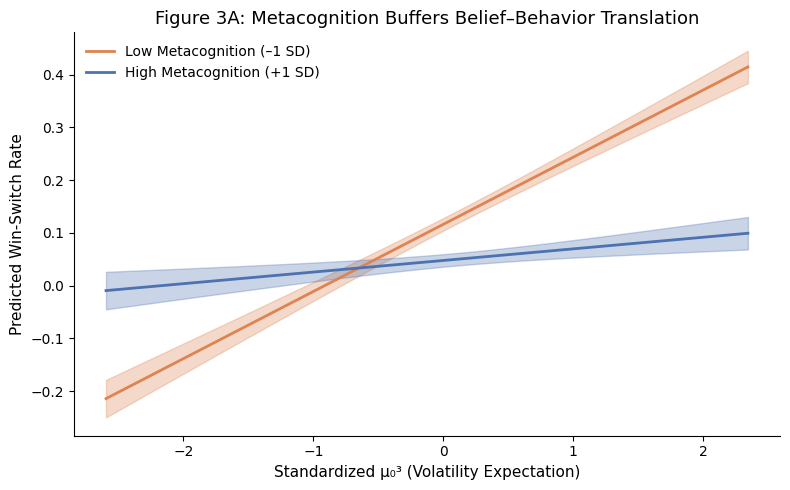


=== Simple Slope Summary Table (Figure 3A) ===
  Metacognition Level  Slope (β)     SE  t-value  p-value
0        +1 SD (High)      0.022  0.008     2.60   0.0096
1         -1 SD (Low)      0.127  0.009    13.87   0.0000


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from scipy.stats import t as t_dist
import seaborn as sns


# === Load and Prepare Data ===
df = pd.read_csv("mp_scores_continuous_500.csv")

# Calculate average MP score across 5 dimensions
mp_columns = [
    'comprehension_continuous',
    'judgment_continuous',
    'evaluation_continuous',
    'final_decision_continuous',
    'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)

# Filter for complete cases
df_moderation = df.dropna(subset=['mu03_avg', 'wsr_avg', 'MP_avg']).copy()

# Standardize predictors
scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z']] = scaler.fit_transform(df_moderation[['mu03_avg', 'MP_avg']])
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# === Model Fit ===
model = smf.ols('wsr_avg ~ mu03_z * MP_z', data=df_moderation).fit()

# === Plotting (Figure 3A) ===
mu_range = np.linspace(df_moderation['mu03_z'].min(), df_moderation['mu03_z'].max(), 100)

def predict_wsr(mu_vals, mp_z_level, model):
    pred = (model.params['Intercept']
            + model.params['mu03_z'] * mu_vals
            + model.params['MP_z'] * mp_z_level
            + model.params['mu03_z:MP_z'] * mu_vals * mp_z_level)
    se = np.sqrt(model.bse['mu03_z']**2
                 + (mu_vals**2 * model.bse['mu03_z:MP_z']**2)
                 + 2 * mu_vals * model.cov_params().loc['mu03_z', 'mu03_z:MP_z'])
    return pred, pred - 1.96 * se, pred + 1.96 * se

wsr_low_mp, low_ci_low, high_ci_low = predict_wsr(mu_range, -1, model)
wsr_high_mp, low_ci_high, high_ci_high = predict_wsr(mu_range, 1, model)

plt.figure(figsize=(8, 5))
plt.plot(mu_range, wsr_low_mp, label='Low Metacognition (–1 SD)', color='#DD8452', linewidth=2)
plt.fill_between(mu_range, low_ci_low, high_ci_low, color='#DD8452', alpha=0.3)
plt.plot(mu_range, wsr_high_mp, label='High Metacognition (+1 SD)', color='#4C72B0', linewidth=2)
plt.fill_between(mu_range, low_ci_high, high_ci_high, color='#4C72B0', alpha=0.3)

plt.xlabel('Standardized μ₀³ (Volatility Expectation)', fontsize=11)
plt.ylabel('Predicted Win-Switch Rate', fontsize=11)
plt.title('Figure 3A: Metacognition Buffers Belief–Behavior Translation', fontsize=13)
plt.legend(frameon=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# === Simple Slopes Table ===
b_mu = model.params['mu03_z']
b_int = model.params['mu03_z:MP_z']
se_mu = model.bse['mu03_z']
se_int = model.bse['mu03_z:MP_z']
covar = model.cov_params().loc['mu03_z', 'mu03_z:MP_z']
df_resid = model.df_resid

def slope_se_fixed(beta_mu, beta_int, se_mu, se_int, covar, mp_val):
    slope = beta_mu + beta_int * mp_val
    se = np.sqrt(se_mu**2 + (mp_val**2 * se_int**2) + 2 * mp_val * covar)
    t_value = slope / se
    p_value = 2 * (1 - t_dist.cdf(np.abs(t_value), df=df_resid))
    return slope, se, t_value, p_value

slope_high, se_high, t_high, p_high = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, 1)
slope_low, se_low, t_low, p_low = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, -1)

summary_table = pd.DataFrame({
    'Metacognition Level': ['+1 SD (High)', '-1 SD (Low)'],
    'Slope (β)': [round(slope_high, 3), round(slope_low, 3)],
    'SE': [round(se_high, 3), round(se_low, 3)],
    't-value': [round(t_high, 2), round(t_low, 2)],
    'p-value': [round(p_high, 4), round(p_low, 4)]
})

# Print results
print("\n=== Simple Slope Summary Table (Figure 3A) ===")
print(summary_table)

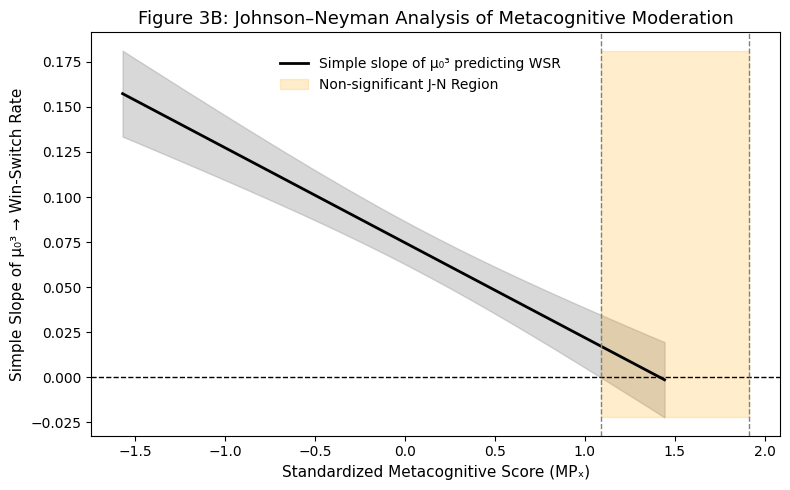

  Metacognition Level  Slope (β)     SE  t-value  p-value
0        +1 SD (High)      0.022  0.008     2.60   0.0096
1         -1 SD (Low)      0.127  0.009    13.87   0.0000

Johnson-Neyman Significant Region: MP_z between 1.09 and 1.91


In [27]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from scipy.stats import t as t_dist

# === Load Data ===
df = pd.read_csv("mp_scores_continuous_500.csv")

# === Calculate average MP score across 5 dimensions ===
mp_columns = [
    'comprehension_continuous', 'judgment_continuous',
    'evaluation_continuous', 'final_decision_continuous', 'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)

# === Filter for needed variables and standardize ===
df_moderation = df.dropna(subset=['mu03_avg', 'wsr_avg', 'MP_avg']).copy()
scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z']] = scaler.fit_transform(df_moderation[['mu03_avg', 'MP_avg']])
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# === Fit Moderation Model ===
model = smf.ols('wsr_avg ~ mu03_z * MP_z', data=df_moderation).fit()

# === Extract Parameters for J-N Analysis ===
b_mu = model.params['mu03_z']
b_int = model.params['mu03_z:MP_z']
se_mu = model.bse['mu03_z']
se_int = model.bse['mu03_z:MP_z']
covar = model.cov_params().loc['mu03_z', 'mu03_z:MP_z']
df_resid = model.df_resid

# === Dynamically Calculate Johnson-Neyman Bounds ===
alpha = 0.05
crit_t = t_dist.ppf(1 - alpha/2, df=df_resid)

A = b_int**2 - (crit_t**2) * (se_int**2)
B = 2 * (b_mu * b_int - (crit_t**2) * covar)
C = b_mu**2 - (crit_t**2) * (se_mu**2)

discriminant = B**2 - 4*A*C
if discriminant >= 0:
    root1 = (-B - np.sqrt(discriminant)) / (2*A)
    root2 = (-B + np.sqrt(discriminant)) / (2*A)
    jn_lower, jn_upper = sorted([root1, root2])
else:
    jn_lower, jn_upper = None, None  # No region where simple slope is non-significant

# === Generate Simple Slopes ===
mp_vals = np.linspace(df_moderation['MP_z'].min(), df_moderation['MP_z'].max(), 300)
slopes = b_mu + b_int * mp_vals
se_slopes = np.sqrt(se_mu**2 + (mp_vals**2 * se_int**2) + 2 * mp_vals * covar)

# === Plot Figure 3B ===
plt.figure(figsize=(8, 5))

# Plot simple slopes with 95% CI
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot(mp_vals, slopes, color='black', linewidth=2, label='Simple slope of μ₀³ predicting WSR')
plt.fill_between(mp_vals, slopes - 1.96 * se_slopes, slopes + 1.96 * se_slopes, color='gray', alpha=0.3)

# Highlight J-N non-significant region
if jn_lower is not None and jn_upper is not None:
    plt.axvline(x=jn_lower, color='gray', linestyle='--', linewidth=1)
    plt.axvline(x=jn_upper, color='gray', linestyle='--', linewidth=1)
    plt.fill_betweenx(
        y=[min(slopes - 1.96 * se_slopes), max(slopes + 1.96 * se_slopes)],
        x1=jn_lower, x2=jn_upper,
        color='orange', alpha=0.2, label='Non-significant J-N Region'
    )

# Final plot styling
plt.xlabel('Standardized Metacognitive Score (MPₓ)', fontsize=11)
plt.ylabel('Simple Slope of μ₀³ → Win-Switch Rate', fontsize=11)
plt.title('Figure 3B: Johnson–Neyman Analysis of Metacognitive Moderation', fontsize=13)
plt.legend(frameon=False, loc='upper right', bbox_to_anchor = (0.7,0.97))
plt.grid(False)
plt.tight_layout()
plt.show()

# === Generate Summary Table ===
def slope_se_fixed(beta_mu, beta_int, se_mu, se_int, covar, mp_val):
    slope = beta_mu + beta_int * mp_val
    se = np.sqrt(se_mu**2 + (mp_val**2 * se_int**2) + 2 * mp_val * covar)
    t_value = slope / se
    p_value = 2 * (1 - t_dist.cdf(np.abs(t_value), df=df_resid))
    return slope, se, t_value, p_value

# Simple slopes at +1SD (high metacognition) and -1SD (low metacognition)
slope_high, se_high, t_high, p_high = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, 1)
slope_low, se_low, t_low, p_low = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, -1)

# Output Table
summary_table = pd.DataFrame({
    'Metacognition Level': ['+1 SD (High)', '-1 SD (Low)'],
    'Slope (β)': [round(slope_high, 3), round(slope_low, 3)],
    'SE': [round(se_high, 3), round(se_low, 3)],
    't-value': [round(t_high, 2), round(t_low, 2)],
    'p-value': [round(p_high, 4), round(p_low, 4)]
})

# Display the table
print(summary_table)

# Also print Johnson-Neyman Bounds
print(f"\nJohnson-Neyman Significant Region: MP_z between {jn_lower:.2f} and {jn_upper:.2f}")


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from scipy.stats import t as t_dist
import seaborn as sns
from scipy.stats import ttest_ind


# === Load and Prepare Data ===
df = pd.read_csv("mp_scores_continuous_500.csv")

# Calculate average MP score across 5 dimensions
mp_columns = [
    'comprehension_continuous',
    'judgment_continuous',
    'evaluation_continuous',
    'final_decision_continuous',
    'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)

# Compute reflection length
df['reflection_length'] = df['combined_reflection'].fillna('').apply(len)

# Filter for complete cases
df_moderation = df.dropna(subset=['mu03_avg', 'wsr_avg', 'MP_avg', 'reflection_length']).copy()

# Standardize predictors
scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z', 'refl_z']] = scaler.fit_transform(
    df_moderation[['mu03_avg', 'MP_avg', 'reflection_length']]
)
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# Fit model controlling for reflection length
model_control = smf.ols('wsr_avg ~ mu03_z * MP_z + refl_z', data=df_moderation).fit()

# Compute simple slopes
b_mu = model_control.params['mu03_z']
b_int = model_control.params['mu03_z:MP_z']
se_mu = model_control.bse['mu03_z']
se_int = model_control.bse['mu03_z:MP_z']
covar = model_control.cov_params().loc['mu03_z', 'mu03_z:MP_z']
df_resid = model_control.df_resid

def slope_se_fixed(beta_mu, beta_int, se_mu, se_int, covar, mp_val):
    slope = beta_mu + beta_int * mp_val
    se = np.sqrt(se_mu**2 + (mp_val**2 * se_int**2) + 2 * mp_val * covar)
    t_value = slope / se
    p_value = 2 * (1 - t_dist.cdf(np.abs(t_value), df=df_resid))
    return slope, se, t_value, p_value

slope_high, se_high, t_high, p_high = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, 1)
slope_low, se_low, t_low, p_low = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, -1)

summary_table = pd.DataFrame({
    'Metacognition Level': ['+1 SD (High)', '-1 SD (Low)'],
    'Slope (β)': [round(slope_high, 3), round(slope_low, 3)],
    'SE': [round(se_high, 3), round(se_low, 3)],
    't-value': [round(t_high, 2), round(t_low, 2)],
    'p-value': [round(p_high, 4), round(p_low, 4)]
})

print(summary_table)


  Metacognition Level  Slope (β)     SE  t-value  p-value
0        +1 SD (High)      0.022  0.009     2.55   0.0111
1         -1 SD (Low)      0.127  0.009    13.84   0.0000


In [35]:
# Extract the full regression coefficients table for inspection
regression_table = pd.DataFrame({
    'Predictor': model_control.params.index,
    'β (Coefficient)': model_control.params.values,
    'SE': model_control.bse.values,
    't-value': model_control.tvalues.values,
    'p-value': model_control.pvalues.values
})

print(regression_table)

     Predictor  β (Coefficient)        SE    t-value       p-value
0    Intercept         0.081876  0.006090  13.443385  3.335152e-35
1       mu03_z         0.074422  0.006106  12.188912  5.717548e-30
2         MP_z        -0.035749  0.007241  -4.936811  1.096876e-06
3  mu03_z:MP_z        -0.052732  0.006408  -8.229654  1.775924e-15
4       refl_z         0.002823  0.006940   0.406749  6.843736e-01


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from scipy.stats import t as t_dist

# Load the dataset
df = pd.read_csv("mp_scores_continuous_500.csv")

# === Recode education_level using structured mapping ===
education_group_map = {
    'Less than a high school diploma': 1,
    'High school degree or equivalent (e.g., GED)': 2,
    'Some college or university, no degree': 3,
    'Associate degree (e.g., AA, AS)': 4,
    "Bachelor's degree (e.g., BA, BS)": 5,
    "Master's degree (e.g., MA, MS, MEd)": 6,
    'Completed some postgraduate': 7,
    'Doctorate or professional degree (e.g., PhD, MD, JD)': 8,
    'Decline to answer': np.nan,
    'Not specified': np.nan
}
df['education_level'] = df['education_level'].map(education_group_map)

# === Clean and score CRT responses ===
import re

def clean_answer(ans):
    if pd.isna(ans):
        return ''
    ans = str(ans).lower().strip()
    ans = re.sub(r'[^a-z0-9]', '', ans)
    return ans

# Apply cleaning
df['CRT1_clean'] = df['cognitive_reflection_1'].apply(clean_answer)
df['CRT2_clean'] = df['cognitive_reflection_2'].apply(clean_answer)
df['CRT3_clean'] = df['cognitive_reflection_3'].apply(clean_answer)

# Define correct sets
crt1_correct = {'5', '005', '0.05', '$0.05', 'five', '5cents'}
crt2_correct = {'5', 'five', '5minutes'}
crt3_correct = {'47', 'fortyseven', '47days'}

# Score CRT
df['cognitive_reflection_1'] = df['CRT1_clean'].isin(crt1_correct).astype(int)
df['cognitive_reflection_2'] = df['CRT2_clean'].isin(crt2_correct).astype(int)
df['cognitive_reflection_3'] = df['CRT3_clean'].isin(crt3_correct).astype(int)

# Compute average CRT score and general cognition
df['CRT_avg'] = df[['cognitive_reflection_1', 'cognitive_reflection_2', 'cognitive_reflection_3']].mean(axis=1)
df['general_cognition'] = df[['education_level', 'CRT_avg']].mean(axis=1)

# === Metacognition and Reflection Length ===
mp_columns = [
    'comprehension_continuous',
    'judgment_continuous',
    'evaluation_continuous',
    'final_decision_continuous',
    'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)
df['reflection_length'] = df['combined_reflection'].fillna('').apply(len)

# === Filter and standardize ===
required = ['mu03_avg', 'wsr_avg', 'MP_avg', 'reflection_length', 'general_cognition']
df_moderation = df.dropna(subset=required).copy()

scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z', 'refl_z', 'gcog_z']] = scaler.fit_transform(
    df_moderation[['mu03_avg', 'MP_avg', 'reflection_length', 'general_cognition']]
)
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# === Fit model ===
model_control = smf.ols('wsr_avg ~ mu03_z * MP_z + refl_z + gcog_z', data=df_moderation).fit()
#model_control = smf.ols('wsr_avg ~ mu03_z * MP_z * refl_z', data=df_moderation).fit()
#model_control = smf.ols('wsr_avg ~ mu03_z * refl_z', data=df_moderation).fit()
# === Create full regression table ===
regression_table = pd.DataFrame({
    'Predictor': model_control.params.index,
    'β (Coefficient)': model_control.params.values,
    'SE': model_control.bse.values,
    't-value': model_control.tvalues.values,
    'p-value': model_control.pvalues.values
})
regression_table = regression_table.round({'β (Coefficient)': 4, 'SE': 4, 't-value': 2, 'p-value': 4})

print(regression_table)

       Predictor  β (Coefficient)      SE  t-value  p-value
0      Intercept           0.0946  0.0064    14.71   0.0000
1         mu03_z           0.0816  0.0064    12.66   0.0000
2         refl_z          -0.0120  0.0077    -1.56   0.1188
3  mu03_z:refl_z          -0.0165  0.0069    -2.39   0.0173


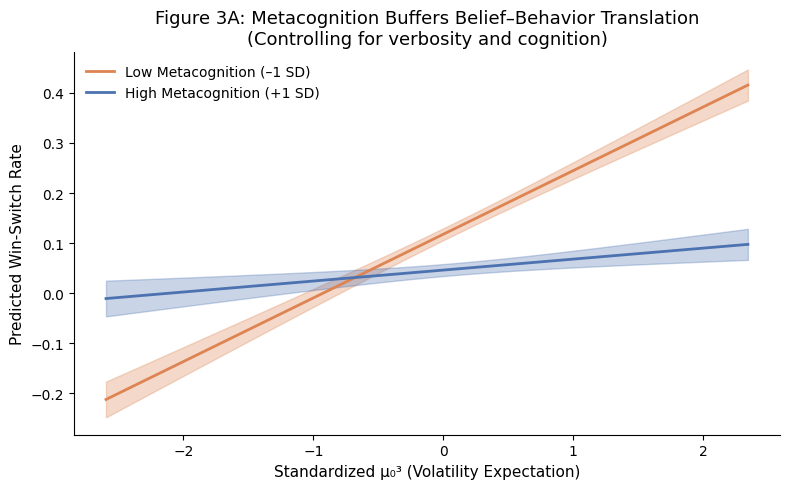


=== Simple Slope Summary Table (Figure 3A) ===
  Metacognition Level  Slope (β)     SE  t-value  p-value
0        +1 SD (High)      0.022  0.009     2.57   0.0106
1         -1 SD (Low)      0.127  0.009    13.82   0.0000


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from scipy.stats import t as t_dist
import seaborn as sns
import re

# === Load and Prepare Data ===
df = pd.read_csv("mp_scores_continuous_500.csv")

# --- Scoring CRT (robust to formats) ---
def clean_answer(ans):
    if pd.isna(ans):
        return ''
    ans = str(ans).lower().strip()
    ans = re.sub(r'[^a-z0-9]', '', ans)
    return ans

crt1_correct = {'5', '005', '0.05', '$0.05', 'five', '5cents'}
crt2_correct = {'5', 'five', '5minutes'}
crt3_correct = {'47', 'fortyseven', '47days'}

df['CRT1_clean'] = df['cognitive_reflection_1'].apply(clean_answer)
df['CRT2_clean'] = df['cognitive_reflection_2'].apply(clean_answer)
df['CRT3_clean'] = df['cognitive_reflection_3'].apply(clean_answer)

df['cognitive_reflection_1'] = df['CRT1_clean'].isin(crt1_correct).astype(int)
df['cognitive_reflection_2'] = df['CRT2_clean'].isin(crt2_correct).astype(int)
df['cognitive_reflection_3'] = df['CRT3_clean'].isin(crt3_correct).astype(int)

df['CRT_avg'] = df[['cognitive_reflection_1', 'cognitive_reflection_2', 'cognitive_reflection_3']].mean(axis=1)

# Recode education levels to ordinal
education_group_map = {
    'Less than a high school diploma': 1,
    'High school degree or equivalent (e.g., GED)': 2,
    'Some college or university, no degree': 3,
    'Associate degree (e.g., AA, AS)': 4,
    "Bachelor's degree (e.g., BA, BS)": 5,
    "Master's degree (e.g., MA, MS, MEd)": 6,
    'Completed some postgraduate': 7,
    'Doctorate or professional degree (e.g., PhD, MD, JD)': 8
}
df['education_level'] = df['education_level'].map(education_group_map)
df['general_cognition'] = df[['education_level', 'CRT_avg']].mean(axis=1)

# Metacognitive scores
mp_columns = [
    'comprehension_continuous', 'judgment_continuous',
    'evaluation_continuous', 'final_decision_continuous', 'confidence_continuous'
]
df['MP_avg'] = df[mp_columns].mean(axis=1)

# Reflection verbosity
df['reflection_length'] = df['combined_reflection'].fillna('').apply(len)

# Filter for complete data
df_moderation = df.dropna(subset=[
    'mu03_avg', 'wsr_avg', 'MP_avg', 'reflection_length', 'general_cognition'
]).copy()

# Standardize predictors
scaler = StandardScaler()
df_moderation[['mu03_z', 'MP_z', 'refl_z', 'gcog_z']] = scaler.fit_transform(
    df_moderation[['mu03_avg', 'MP_avg', 'reflection_length', 'general_cognition']]
)
df_moderation['interaction'] = df_moderation['mu03_z'] * df_moderation['MP_z']

# === Model Fit ===
model = smf.ols('wsr_avg ~ mu03_z * MP_z + refl_z + gcog_z', data=df_moderation).fit()

# === Plotting (Figure 3A, adjusted) ===
mu_range = np.linspace(df_moderation['mu03_z'].min(), df_moderation['mu03_z'].max(), 100)

def predict_wsr(mu_vals, mp_z_level, model, refl_z=0, gcog_z=0):
    pred = (model.params['Intercept']
            + model.params['mu03_z'] * mu_vals
            + model.params['MP_z'] * mp_z_level
            + model.params['mu03_z:MP_z'] * mu_vals * mp_z_level
            + model.params['refl_z'] * refl_z
            + model.params['gcog_z'] * gcog_z)
    
    se = np.sqrt(model.bse['mu03_z']**2
                 + (mu_vals**2 * model.bse['mu03_z:MP_z']**2)
                 + 2 * mu_vals * model.cov_params().loc['mu03_z', 'mu03_z:MP_z'])
    return pred, pred - 1.96 * se, pred + 1.96 * se

wsr_low_mp, low_ci_low, high_ci_low = predict_wsr(mu_range, -1, model)
wsr_high_mp, low_ci_high, high_ci_high = predict_wsr(mu_range, 1, model)

plt.figure(figsize=(8, 5))
plt.plot(mu_range, wsr_low_mp, label='Low Metacognition (–1 SD)', color='#DD8452', linewidth=2)
plt.fill_between(mu_range, low_ci_low, high_ci_low, color='#DD8452', alpha=0.3)
plt.plot(mu_range, wsr_high_mp, label='High Metacognition (+1 SD)', color='#4C72B0', linewidth=2)
plt.fill_between(mu_range, low_ci_high, high_ci_high, color='#4C72B0', alpha=0.3)

plt.xlabel('Standardized μ₀³ (Volatility Expectation)', fontsize=11)
plt.ylabel('Predicted Win-Switch Rate', fontsize=11)
plt.title('Figure 3A: Metacognition Buffers Belief–Behavior Translation\n(Controlling for verbosity and cognition)', fontsize=13)
plt.legend(frameon=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# === Simple Slopes Table ===
b_mu = model.params['mu03_z']
b_int = model.params['mu03_z:MP_z']
se_mu = model.bse['mu03_z']
se_int = model.bse['mu03_z:MP_z']
covar = model.cov_params().loc['mu03_z', 'mu03_z:MP_z']
df_resid = model.df_resid

def slope_se_fixed(beta_mu, beta_int, se_mu, se_int, covar, mp_val):
    slope = beta_mu + beta_int * mp_val
    se = np.sqrt(se_mu**2 + (mp_val**2 * se_int**2) + 2 * mp_val * covar)
    t_value = slope / se
    p_value = 2 * (1 - t_dist.cdf(np.abs(t_value), df=df_resid))
    return slope, se, t_value, p_value

slope_high, se_high, t_high, p_high = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, 1)
slope_low, se_low, t_low, p_low = slope_se_fixed(b_mu, b_int, se_mu, se_int, covar, -1)

summary_table = pd.DataFrame({
    'Metacognition Level': ['+1 SD (High)', '-1 SD (Low)'],
    'Slope (β)': [round(slope_high, 3), round(slope_low, 3)],
    'SE': [round(se_high, 3), round(se_low, 3)],
    't-value': [round(t_high, 2), round(t_low, 2)],
    'p-value': [round(p_high, 4), round(p_low, 4)]
})

# Print results
print("\n=== Simple Slope Summary Table (Figure 3A) ===")
print(summary_table)
